In [1]:
from keras.layers import Concatenate
import seaborn as sb
import os
from PIL import Image
from keras.layers import Input
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import KFold
import numpy as np
import cv2
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import MaxPooling2D, Flatten, Conv2D, Dense, BatchNormalization, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.densenet import DenseNet169
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
real_image_weights = np.ones(1191) * 3
fake_image_weights = np.ones(1000)
weights = np.concatenate([real_image_weights, fake_image_weights])

In [2]:
X_Train = []
for image in os.listdir('ProjectBackUp/Images/dataReal'):
    img = Image.open('ProjectBackUp/Images/dataReal/' + image)
    img = img.resize((128, 128))
    X_Train.append(np.array(img) / 255)
for image in os.listdir('ProjectBackUp/Images/dataFake'):
    img = Image.open('ProjectBackUp/Images/dataFake/' + image)
    img = img.resize((128, 128))
    X_Train.append(np.array(img) / 255)

In [3]:
Y_Train_Am = []
Y_Train_Ch = []
df1 = pd.read_csv('ProjectBackUp/CSV/Ammonia.csv', header = None)
df2 = pd.read_csv('ProjectBackUp/CSV/Chlorophyll.csv', header = None)
df1 = df1.to_numpy()
df2 = df2.to_numpy()
for i in range(len(df1)):
    Y_Train_Am.append([df1[i]])
    Y_Train_Ch.append([df2[i]])

In [4]:
X_Train = np.array(X_Train)
Y_Train_Am = np.array(Y_Train_Am)
Y_Train_Ch = np.array(Y_Train_Ch)
Y_Train_Am = Y_Train_Am.reshape(Y_Train_Am.shape[0], 1, 1)
Y_Train_Ch = Y_Train_Ch.reshape(Y_Train_Ch.shape[0], 1, 1)

In [5]:
kfold = KFold(n_splits = 10, shuffle = True)

In [6]:
@tf.function
def RSquare(y, prediction):
    unexplained_error = tf.reduce_sum(tf.square(tf.subtract(y, prediction)))
    total_error = tf.reduce_sum(tf.square(tf.subtract(y, tf.reduce_mean(y))))
    R_squared = tf.subtract(1.0, tf.divide(unexplained_error, total_error))
    return R_squared

In [7]:
epochs = 30
batch_size = 16

In [17]:
fold = 1
histories_Am = []
for train, test in kfold.split(X_Train, Y_Train_Am):
    in_shape = (128, 128, 3)
    in_layer = Input(shape = in_shape)
    mobilenet = MobileNetV2(weights = 'imagenet', input_shape = in_shape, include_top = False)
    densenet = DenseNet169(weights = 'imagenet', input_shape = in_shape, include_top = False)
    for layer in mobilenet.layers:
        layer.trainable = False
    for layer in densenet.layers:
        layer.trainable = False
    model_mobilenet = mobilenet(in_layer)
    model_mobilenet = GlobalAveragePooling2D()(model_mobilenet)
    output_mobilenet = Flatten()(model_mobilenet)
    model_densenet = densenet(in_layer)
    model_densenet = GlobalAveragePooling2D()(model_densenet)
    output_densenet = Flatten()(model_densenet)
    concatenated = Concatenate()([output_mobilenet, output_densenet])
    X = Dense(1024, activation = 'relu')(concatenated)
    X = Dropout(0.5)(X)
    X = Dense(1, activation = 'linear')(X)
    model = tf.keras.models.Model(inputs = in_layer, outputs = X)
    optim = Adam(learning_rate = 0.001)
    model.compile(loss = 'mean_squared_error', optimizer = optim, metrics = ['RootMeanSquaredError', RSquare, 'mse'])
    rlr = ReduceLROnPlateau(monitor = "val_loss", factor = 0.01, patience = 6, verbose = 0, mode = "max", min_delta = 0.01)
    model_save = ModelCheckpoint('10-Folds/10-Folds 1R,2F/stacked_model_Ammonia_' + str(fold) + '.h5', save_best_only = True, save_weights_only = False, monitor = 'val_loss', mode = 'min', verbose = 1)
    history = model.fit(X_Train[train], Y_Train_Am[train], epochs = epochs, validation_data = (X_Train[test], Y_Train_Am[test]), callbacks = [rlr, model_save], sample_weight = weights[train])
    fold += 1
    histories_Am.append(history)

Epoch 1/30
62/62 [==============================] - ETA: 0s - loss: 5165.2373 - root_mean_squared_error: 45.0387 - RSquare: 0.0389 - mse: 2028.4843
Epoch 1: val_loss improved from inf to 3271.07397, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_1.h5
62/62 [==============================] - 47s 363ms/step - loss: 5165.2373 - root_mean_squared_error: 45.0387 - RSquare: 0.0389 - mse: 2028.4843 - val_loss: 3271.0740 - val_root_mean_squared_error: 57.1933 - val_RSquare: -0.1751 - val_mse: 3271.0740 - lr: 0.0010
Epoch 2/30
62/62 [==============================] - ETA: 0s - loss: 4281.7393 - root_mean_squared_error: 40.9797 - RSquare: 0.2001 - mse: 1679.3363
Epoch 2: val_loss improved from 3271.07397 to 2994.66162, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_1.h5
62/62 [==============================] - 10s 164ms/step - loss: 4281.7393 - root_mean_squared_error: 40.9797 - RSquare: 0.2001 - mse: 1679.3363 - val_loss: 2994.6616 - val_root_mean_squared_error: 54

Epoch 17/30
62/62 [==============================] - ETA: 0s - loss: 2567.0989 - root_mean_squared_error: 33.3050 - RSquare: 0.4486 - mse: 1109.2206
Epoch 17: val_loss improved from 2430.55005 to 2430.43555, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_1.h5
62/62 [==============================] - 10s 159ms/step - loss: 2567.0989 - root_mean_squared_error: 33.3050 - RSquare: 0.4486 - mse: 1109.2206 - val_loss: 2430.4355 - val_root_mean_squared_error: 49.2994 - val_RSquare: 0.0239 - val_mse: 2430.4355 - lr: 1.0000e-07
Epoch 18/30
62/62 [==============================] - ETA: 0s - loss: 2591.3833 - root_mean_squared_error: 33.4124 - RSquare: 0.4573 - mse: 1116.3859
Epoch 18: val_loss improved from 2430.43555 to 2430.39624, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_1.h5
62/62 [==============================] - 10s 158ms/step - loss: 2591.3833 - root_mean_squared_error: 33.4124 - RSquare: 0.4573 - mse: 1116.3859 - val_loss: 2430.3962 - val_root_mean_squ

62/62 [==============================] - 11s 171ms/step - loss: 4136.6353 - root_mean_squared_error: 40.6044 - RSquare: 0.2414 - mse: 1648.7153 - val_loss: 1853.8317 - val_root_mean_squared_error: 43.0561 - val_RSquare: -0.0230 - val_mse: 1853.8317 - lr: 0.0010
Epoch 4/30
62/62 [==============================] - ETA: 0s - loss: 3831.1123 - root_mean_squared_error: 39.3498 - RSquare: 0.2817 - mse: 1548.4058
Epoch 4: val_loss improved from 1853.83167 to 1773.00269, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_2.h5
62/62 [==============================] - 10s 168ms/step - loss: 3831.1123 - root_mean_squared_error: 39.3498 - RSquare: 0.2817 - mse: 1548.4058 - val_loss: 1773.0027 - val_root_mean_squared_error: 42.1070 - val_RSquare: -0.0082 - val_mse: 1773.0027 - lr: 0.0010
Epoch 5/30
62/62 [==============================] - ETA: 0s - loss: 3488.9202 - root_mean_squared_error: 37.8066 - RSquare: 0.3374 - mse: 1429.3392
Epoch 5: val_loss improved from 1773.00269 to 1741.7862

Epoch 19/30
62/62 [==============================] - ETA: 0s - loss: 2805.5784 - root_mean_squared_error: 34.3945 - RSquare: 0.4562 - mse: 1182.9788
Epoch 19: val_loss improved from 1644.69653 to 1644.69006, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_2.h5
62/62 [==============================] - 11s 175ms/step - loss: 2805.5784 - root_mean_squared_error: 34.3945 - RSquare: 0.4562 - mse: 1182.9788 - val_loss: 1644.6901 - val_root_mean_squared_error: 40.5548 - val_RSquare: -0.0091 - val_mse: 1644.6901 - lr: 1.0000e-07
Epoch 20/30
62/62 [==============================] - ETA: 0s - loss: 2765.2751 - root_mean_squared_error: 34.2467 - RSquare: 0.4404 - mse: 1172.8333
Epoch 20: val_loss did not improve from 1644.69006
62/62 [==============================] - 9s 138ms/step - loss: 2765.2751 - root_mean_squared_error: 34.2467 - RSquare: 0.4404 - mse: 1172.8333 - val_loss: 1644.6901 - val_root_mean_squared_error: 40.5548 - val_RSquare: -0.0091 - val_mse: 1644.6901 - lr: 1.000

Epoch 6/30
62/62 [==============================] - ETA: 0s - loss: 3297.8523 - root_mean_squared_error: 37.0426 - RSquare: 0.3602 - mse: 1372.1573
Epoch 6: val_loss improved from 1549.91699 to 1436.68750, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_3.h5
62/62 [==============================] - 12s 189ms/step - loss: 3297.8523 - root_mean_squared_error: 37.0426 - RSquare: 0.3602 - mse: 1372.1573 - val_loss: 1436.6875 - val_root_mean_squared_error: 37.9037 - val_RSquare: -0.0687 - val_mse: 1436.6875 - lr: 0.0010
Epoch 7/30
62/62 [==============================] - ETA: 0s - loss: 3203.5286 - root_mean_squared_error: 36.8458 - RSquare: 0.3643 - mse: 1357.6112
Epoch 7: val_loss improved from 1436.68750 to 1404.76526, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_3.h5
62/62 [==============================] - 11s 180ms/step - loss: 3203.5286 - root_mean_squared_error: 36.8458 - RSquare: 0.3643 - mse: 1357.6112 - val_loss: 1404.7653 - val_root_mean_squared_er

...

Epoch 24/30
62/62 [==============================] - ETA: 0s - loss: 2822.5845 - root_mean_squared_error: 34.6932 - RSquare: 0.4478 - mse: 1203.6156
Epoch 24: val_loss did not improve from 986.09839
62/62 [==============================] - 8s 130ms/step - loss: 2822.5845 - root_mean_squared_error: 34.6932 - RSquare: 0.4478 - mse: 1203.6156 - val_loss: 1055.6992 - val_root_mean_squared_error: 32.4915 - val_RSquare: -0.1139 - val_mse: 1055.6992 - lr: 1.0000e-09
Epoch 25/30
62/62 [==============================] - ETA: 0s - loss: 2827.3467 - root_mean_squared_error: 34.7501 - RSquare: 0.4498 - mse: 1207.5709
Epoch 25: val_loss did not improve from 986.09839
62/62 [==============================] - 8s 128ms/step - loss: 2827.3467 - root_mean_squared_error: 34.7501 - RSquare: 0.4498 - mse: 1207.5709 - val_loss: 1055.6993 - val_root_mean_squared_error: 32.4915 - val_RSquare: -0.1139 - val_mse: 1055.6993 - lr: 1.0000e-09
Epoch 26/30
62/62 [==============================] - ETA: 0s - loss: 290

62/62 [==============================] - ETA: 0s - loss: 2795.6667 - root_mean_squared_error: 34.4520 - RSquare: 0.4314 - mse: 1186.9374
Epoch 10: val_loss improved from 1821.44617 to 1820.00867, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_9.h5
62/62 [==============================] - 11s 182ms/step - loss: 2795.6667 - root_mean_squared_error: 34.4520 - RSquare: 0.4314 - mse: 1186.9374 - val_loss: 1820.0087 - val_root_mean_squared_error: 42.6616 - val_RSquare: -0.0114 - val_mse: 1820.0087 - lr: 1.0000e-05
Epoch 11/30
62/62 [==============================] - ETA: 0s - loss: 2761.2244 - root_mean_squared_error: 34.1516 - RSquare: 0.4364 - mse: 1166.3307
Epoch 11: val_loss improved from 1820.00867 to 1818.56152, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_9.h5
62/62 [==============================] - 11s 175ms/step - loss: 2761.2244 - root_mean_squared_error: 34.1516 - RSquare: 0.4364 - mse: 1166.3307 - val_loss: 1818.5615 - val_root_mean_squared_error:

Epoch 26/30
62/62 [==============================] - ETA: 0s - loss: 2748.6609 - root_mean_squared_error: 34.1919 - RSquare: 0.4361 - mse: 1169.0853
Epoch 26: val_loss did not improve from 1816.12683
62/62 [==============================] - 8s 128ms/step - loss: 2748.6609 - root_mean_squared_error: 34.1919 - RSquare: 0.4361 - mse: 1169.0853 - val_loss: 1816.1268 - val_root_mean_squared_error: 42.6160 - val_RSquare: -7.6510e-04 - val_mse: 1816.1268 - lr: 1.0000e-11
Epoch 27/30
62/62 [==============================] - ETA: 0s - loss: 2755.4922 - root_mean_squared_error: 34.2189 - RSquare: 0.4379 - mse: 1170.9341
Epoch 27: val_loss did not improve from 1816.12683
62/62 [==============================] - 8s 128ms/step - loss: 2755.4922 - root_mean_squared_error: 34.2189 - RSquare: 0.4379 - mse: 1170.9341 - val_loss: 1816.1268 - val_root_mean_squared_error: 42.6160 - val_RSquare: -7.6510e-04 - val_mse: 1816.1268 - lr: 1.0000e-11
Epoch 28/30
62/62 [==============================] - ETA: 0s -

62/62 [==============================] - ETA: 0s - loss: 2890.2883 - root_mean_squared_error: 34.9007 - RSquare: 0.4299 - mse: 1218.0601
Epoch 12: val_loss improved from 1303.90845 to 1302.99304, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Ammonia_10.h5
62/62 [==============================] - 11s 175ms/step - loss: 2890.2883 - root_mean_squared_error: 34.9007 - RSquare: 0.4299 - mse: 1218.0601 - val_loss: 1302.9930 - val_root_mean_squared_error: 36.0970 - val_RSquare: -0.1431 - val_mse: 1302.9930 - lr: 1.0000e-05
Epoch 13/30
62/62 [==============================] - ETA: 0s - loss: 2850.9558 - root_mean_squared_error: 34.8100 - RSquare: 0.4346 - mse: 1211.7379
Epoch 13: val_loss did not improve from 1302.99304
62/62 [==============================] - 9s 143ms/step - loss: 2850.9558 - root_mean_squared_error: 34.8100 - RSquare: 0.4346 - mse: 1211.7379 - val_loss: 1303.2795 - val_root_mean_squared_error: 36.1010 - val_RSquare: -0.1441 - val_mse: 1303.2795 - lr: 1.0000e-05
Epoch

Epoch 30/30
62/62 [==============================] - ETA: 0s - loss: 2822.4631 - root_mean_squared_error: 34.6425 - RSquare: 0.4440 - mse: 1200.1017
Epoch 30: val_loss did not improve from 1302.99304
62/62 [==============================] - 9s 139ms/step - loss: 2822.4631 - root_mean_squared_error: 34.6425 - RSquare: 0.4440 - mse: 1200.1017 - val_loss: 1303.2245 - val_root_mean_squared_error: 36.1002 - val_RSquare: -0.1441 - val_mse: 1303.2245 - lr: 1.0000e-11


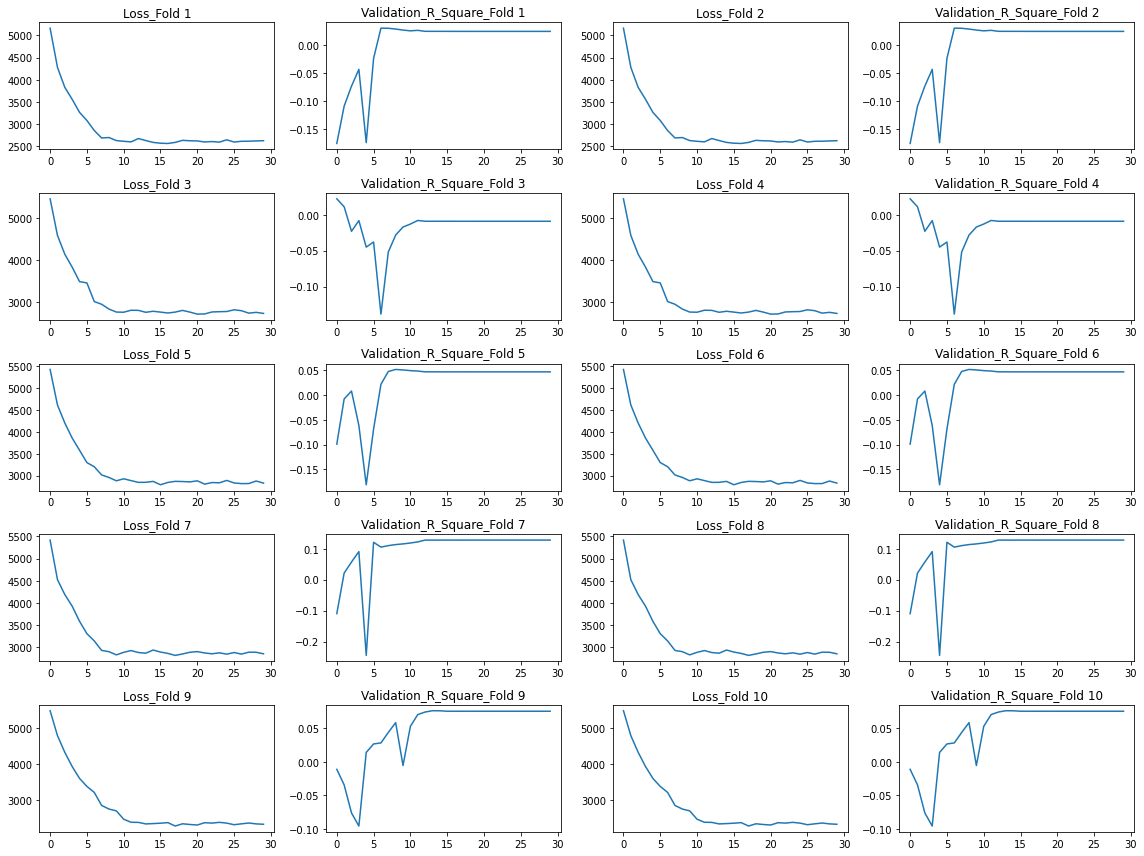

In [18]:
fig, axes = plt.subplots(nrows = 5, ncols = 4, figsize = (16, 12))
index = 0
evOd = 0
for i in range(5):
    for j in range(4):
        if evOd == 0:
            axes[i, j].plot(histories_Am[i].history['loss'])
            axes[i, j].set_title(f'Loss_Fold {index + 1}')
            evOd = 1
        else:
            axes[i, j].plot(histories_Am[i].history['val_RSquare'])
            axes[i, j].set_title(f'Validation_R_Square_Fold {index + 1}')
            evOd = 0
            index += 1
plt.tight_layout()
plt.show()

In [19]:
fold = 1
histories_Ch = []
for train, test in kfold.split(X_Train, Y_Train_Ch):
    in_shape = (128, 128, 3)
    in_layer = Input(shape = in_shape)
    mobilenet = MobileNetV2(weights = 'imagenet', input_shape = in_shape, include_top = False)
    densenet = DenseNet169(weights = 'imagenet', input_shape = in_shape, include_top = False)
    for layer in mobilenet.layers:
        layer.trainable = False
    for layer in densenet.layers:
        layer.trainable = False
    model_mobilenet = mobilenet(in_layer)
    model_mobilenet = GlobalAveragePooling2D()(model_mobilenet)
    output_mobilenet = Flatten()(model_mobilenet)
    model_densenet = densenet(in_layer)
    model_densenet = GlobalAveragePooling2D()(model_densenet)
    output_densenet = Flatten()(model_densenet)
    concatenated = Concatenate()([output_mobilenet, output_densenet])
    X = Dense(1024, activation = 'relu')(concatenated)
    X = Dropout(0.5)(X)
    X = Dense(1, activation = 'linear')(X)
    model = tf.keras.models.Model(inputs = in_layer, outputs = X)
    optim = Adam(learning_rate = 0.001)
    model.compile(loss = 'mean_squared_error', optimizer = optim, metrics = ['RootMeanSquaredError', RSquare, 'mse'])
    rlr = ReduceLROnPlateau(monitor = "val_loss", factor = 0.01, patience = 6, verbose = 0, mode = "max", min_delta = 0.01)
    model_save = ModelCheckpoint('10-Folds/10-Folds 1R,2F/stacked_model_Chlorophyll_' + str(fold) + '.h5', save_best_only = True, save_weights_only = False, monitor = 'val_loss', mode = 'min', verbose = 1)
    history = model.fit(X_Train[train], Y_Train_Ch[train], epochs = epochs, validation_data = (X_Train[test], Y_Train_Ch[test]), callbacks = [rlr, model_save], sample_weight = weights[train])
    fold += 1
    histories_Ch.append(history)

Epoch 1/30
62/62 [==============================] - ETA: 0s - loss: 773.9948 - root_mean_squared_error: 17.8482 - RSquare: -1.0246 - mse: 318.5583
Epoch 1: val_loss improved from inf to 128.65826, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_1.h5
62/62 [==============================] - 34s 272ms/step - loss: 773.9948 - root_mean_squared_error: 17.8482 - RSquare: -1.0246 - mse: 318.5583 - val_loss: 128.6583 - val_root_mean_squared_error: 11.3428 - val_RSquare: -0.3580 - val_mse: 128.6583 - lr: 0.0010
Epoch 2/30
62/62 [==============================] - ETA: 0s - loss: 368.3902 - root_mean_squared_error: 12.0190 - RSquare: 0.0573 - mse: 144.4575
Epoch 2: val_loss improved from 128.65826 to 127.08266, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_1.h5
62/62 [==============================] - 11s 171ms/step - loss: 368.3902 - root_mean_squared_error: 12.0190 - RSquare: 0.0573 - mse: 144.4575 - val_loss: 127.0827 - val_root_mean_squared_error: 11.273

Epoch 18/30
62/62 [==============================] - ETA: 0s - loss: 235.3495 - root_mean_squared_error: 9.7140 - RSquare: 0.3838 - mse: 94.3624
Epoch 18: val_loss did not improve from 106.70797
62/62 [==============================] - 8s 130ms/step - loss: 235.3495 - root_mean_squared_error: 9.7140 - RSquare: 0.3838 - mse: 94.3624 - val_loss: 106.7143 - val_root_mean_squared_error: 10.3303 - val_RSquare: -0.2061 - val_mse: 106.7143 - lr: 1.0000e-07
Epoch 19/30
62/62 [==============================] - ETA: 0s - loss: 251.2163 - root_mean_squared_error: 10.0883 - RSquare: 0.3457 - mse: 101.7746
Epoch 19: val_loss did not improve from 106.70797
62/62 [==============================] - 8s 130ms/step - loss: 251.2163 - root_mean_squared_error: 10.0883 - RSquare: 0.3457 - mse: 101.7746 - val_loss: 106.7166 - val_root_mean_squared_error: 10.3304 - val_RSquare: -0.2062 - val_mse: 106.7166 - lr: 1.0000e-07
Epoch 20/30
62/62 [==============================] - ETA: 0s - loss: 248.3445 - root_mea

Epoch 6/30
62/62 [==============================] - ETA: 0s - loss: 290.3528 - root_mean_squared_error: 10.8528 - RSquare: 0.1995 - mse: 117.7833
Epoch 6: val_loss improved from 128.89374 to 126.46641, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_2.h5
62/62 [==============================] - 10s 161ms/step - loss: 290.3528 - root_mean_squared_error: 10.8528 - RSquare: 0.1995 - mse: 117.7833 - val_loss: 126.4664 - val_root_mean_squared_error: 11.2457 - val_RSquare: -0.0474 - val_mse: 126.4664 - lr: 0.0010
Epoch 7/30
62/62 [==============================] - ETA: 0s - loss: 271.4058 - root_mean_squared_error: 10.4354 - RSquare: 0.2798 - mse: 108.8986
Epoch 7: val_loss improved from 126.46641 to 125.08152, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_2.h5
62/62 [==============================] - 10s 160ms/step - loss: 271.4058 - root_mean_squared_error: 10.4354 - RSquare: 0.2798 - mse: 108.8986 - val_loss: 125.0815 - val_root_mean_squared_error: 11

Epoch 23/30
62/62 [==============================] - ETA: 0s - loss: 226.1279 - root_mean_squared_error: 9.5996 - RSquare: 0.3771 - mse: 92.1514
Epoch 23: val_loss did not improve from 118.26254
62/62 [==============================] - 8s 131ms/step - loss: 226.1279 - root_mean_squared_error: 9.5996 - RSquare: 0.3771 - mse: 92.1514 - val_loss: 118.5138 - val_root_mean_squared_error: 10.8864 - val_RSquare: -3.1131e-05 - val_mse: 118.5138 - lr: 1.0000e-09
Epoch 24/30
62/62 [==============================] - ETA: 0s - loss: 222.8970 - root_mean_squared_error: 9.5430 - RSquare: 0.4034 - mse: 91.0685
Epoch 24: val_loss did not improve from 118.26254
62/62 [==============================] - 8s 131ms/step - loss: 222.8970 - root_mean_squared_error: 9.5430 - RSquare: 0.4034 - mse: 91.0685 - val_loss: 118.5138 - val_root_mean_squared_error: 10.8864 - val_RSquare: -3.1182e-05 - val_mse: 118.5138 - lr: 1.0000e-09
Epoch 25/30
62/62 [==============================] - ETA: 0s - loss: 229.0608 - root

62/62 [==============================] - ETA: 0s - loss: 253.1764 - root_mean_squared_error: 10.1268 - RSquare: 0.3075 - mse: 102.5519
Epoch 10: val_loss improved from 99.78570 to 99.42720, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_3.h5
62/62 [==============================] - 10s 167ms/step - loss: 253.1764 - root_mean_squared_error: 10.1268 - RSquare: 0.3075 - mse: 102.5519 - val_loss: 99.4272 - val_root_mean_squared_error: 9.9713 - val_RSquare: -0.0637 - val_mse: 99.4272 - lr: 1.0000e-05
Epoch 11/30
62/62 [==============================] - ETA: 0s - loss: 228.3100 - root_mean_squared_error: 9.6788 - RSquare: 0.3816 - mse: 93.6797
Epoch 11: val_loss improved from 99.42720 to 99.20551, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_3.h5
62/62 [==============================] - 10s 162ms/step - loss: 228.3100 - root_mean_squared_error: 9.6788 - RSquare: 0.3816 - mse: 93.6797 - val_loss: 99.2055 - val_root_mean_squared_error: 9.9602 - val_RSqua

...

62/62 [==============================] - ETA: 0s - loss: 245.6681 - root_mean_squared_error: 10.0211 - RSquare: 0.3192 - mse: 100.4230
Epoch 13: val_loss improved from 104.20177 to 104.07806, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_8.h5
62/62 [==============================] - 10s 161ms/step - loss: 245.6681 - root_mean_squared_error: 10.0211 - RSquare: 0.3192 - mse: 100.4230 - val_loss: 104.0781 - val_root_mean_squared_error: 10.2019 - val_RSquare: 0.1076 - val_mse: 104.0781 - lr: 1.0000e-05
Epoch 14/30
62/62 [==============================] - ETA: 0s - loss: 249.3238 - root_mean_squared_error: 10.0399 - RSquare: 0.3225 - mse: 100.7989
Epoch 14: val_loss did not improve from 104.07806
62/62 [==============================] - 8s 131ms/step - loss: 249.3238 - root_mean_squared_error: 10.0399 - RSquare: 0.3225 - mse: 100.7989 - val_loss: 104.0787 - val_root_mean_squared_error: 10.2019 - val_RSquare: 0.1076 - val_mse: 104.0787 - lr: 1.0000e-07
Epoch 15/30
62/62 [

Epoch 1/30
62/62 [==============================] - ETA: 0s - loss: 720.9819 - root_mean_squared_error: 17.3786 - RSquare: -1.1238 - mse: 302.0161
Epoch 1: val_loss improved from inf to 142.65639, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_9.h5
62/62 [==============================] - 31s 246ms/step - loss: 720.9819 - root_mean_squared_error: 17.3786 - RSquare: -1.1238 - mse: 302.0161 - val_loss: 142.6564 - val_root_mean_squared_error: 11.9439 - val_RSquare: -0.3118 - val_mse: 142.6564 - lr: 0.0010
Epoch 2/30
62/62 [==============================] - ETA: 0s - loss: 375.7889 - root_mean_squared_error: 12.1220 - RSquare: 0.0661 - mse: 146.9422
Epoch 2: val_loss improved from 142.65639 to 121.25200, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_9.h5
62/62 [==============================] - 10s 164ms/step - loss: 375.7889 - root_mean_squared_error: 12.1220 - RSquare: 0.0661 - mse: 146.9422 - val_loss: 121.2520 - val_root_mean_squared_error: 11.011

Epoch 17/30
62/62 [==============================] - ETA: 0s - loss: 249.3465 - root_mean_squared_error: 9.9965 - RSquare: 0.3378 - mse: 99.9298  
Epoch 17: val_loss improved from 108.30679 to 108.30425, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_9.h5
62/62 [==============================] - 10s 160ms/step - loss: 249.3465 - root_mean_squared_error: 9.9965 - RSquare: 0.3378 - mse: 99.9298 - val_loss: 108.3043 - val_root_mean_squared_error: 10.4069 - val_RSquare: -0.0690 - val_mse: 108.3043 - lr: 1.0000e-07
Epoch 18/30
62/62 [==============================] - ETA: 0s - loss: 249.7206 - root_mean_squared_error: 10.0672 - RSquare: 0.3318 - mse: 101.3482
Epoch 18: val_loss improved from 108.30425 to 108.30068, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_9.h5
62/62 [==============================] - 10s 158ms/step - loss: 249.7206 - root_mean_squared_error: 10.0672 - RSquare: 0.3318 - mse: 101.3482 - val_loss: 108.3007 - val_root_mean_squared_err

62/62 [==============================] - ETA: 0s - loss: 341.1673 - root_mean_squared_error: 11.5998 - RSquare: 0.1208 - mse: 134.5555
Epoch 3: val_loss did not improve from 128.70436
62/62 [==============================] - 8s 127ms/step - loss: 341.1673 - root_mean_squared_error: 11.5998 - RSquare: 0.1208 - mse: 134.5555 - val_loss: 135.7069 - val_root_mean_squared_error: 11.6493 - val_RSquare: -0.0288 - val_mse: 135.7069 - lr: 0.0010
Epoch 4/30
62/62 [==============================] - ETA: 0s - loss: 315.6207 - root_mean_squared_error: 11.1860 - RSquare: 0.1840 - mse: 125.1255
Epoch 4: val_loss improved from 128.70436 to 121.65667, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_10.h5
62/62 [==============================] - 10s 158ms/step - loss: 315.6207 - root_mean_squared_error: 11.1860 - RSquare: 0.1840 - mse: 125.1255 - val_loss: 121.6567 - val_root_mean_squared_error: 11.0298 - val_RSquare: 0.0752 - val_mse: 121.6567 - lr: 0.0010
Epoch 5/30
62/62 [==========

62/62 [==============================] - ETA: 0s - loss: 241.7360 - root_mean_squared_error: 9.8838 - RSquare: 0.3213 - mse: 97.6888
Epoch 19: val_loss improved from 121.38415 to 121.38409, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_10.h5
62/62 [==============================] - 10s 159ms/step - loss: 241.7360 - root_mean_squared_error: 9.8838 - RSquare: 0.3213 - mse: 97.6888 - val_loss: 121.3841 - val_root_mean_squared_error: 11.0174 - val_RSquare: 0.0696 - val_mse: 121.3841 - lr: 1.0000e-07
Epoch 20/30
62/62 [==============================] - ETA: 0s - loss: 241.5715 - root_mean_squared_error: 9.8408 - RSquare: 0.3512 - mse: 96.8416
Epoch 20: val_loss improved from 121.38409 to 121.38408, saving model to 10-Folds/10-Folds 1R,2F\stacked_model_Chlorophyll_10.h5
62/62 [==============================] - 10s 158ms/step - loss: 241.5715 - root_mean_squared_error: 9.8408 - RSquare: 0.3512 - mse: 96.8416 - val_loss: 121.3841 - val_root_mean_squared_error: 11.0174 - val

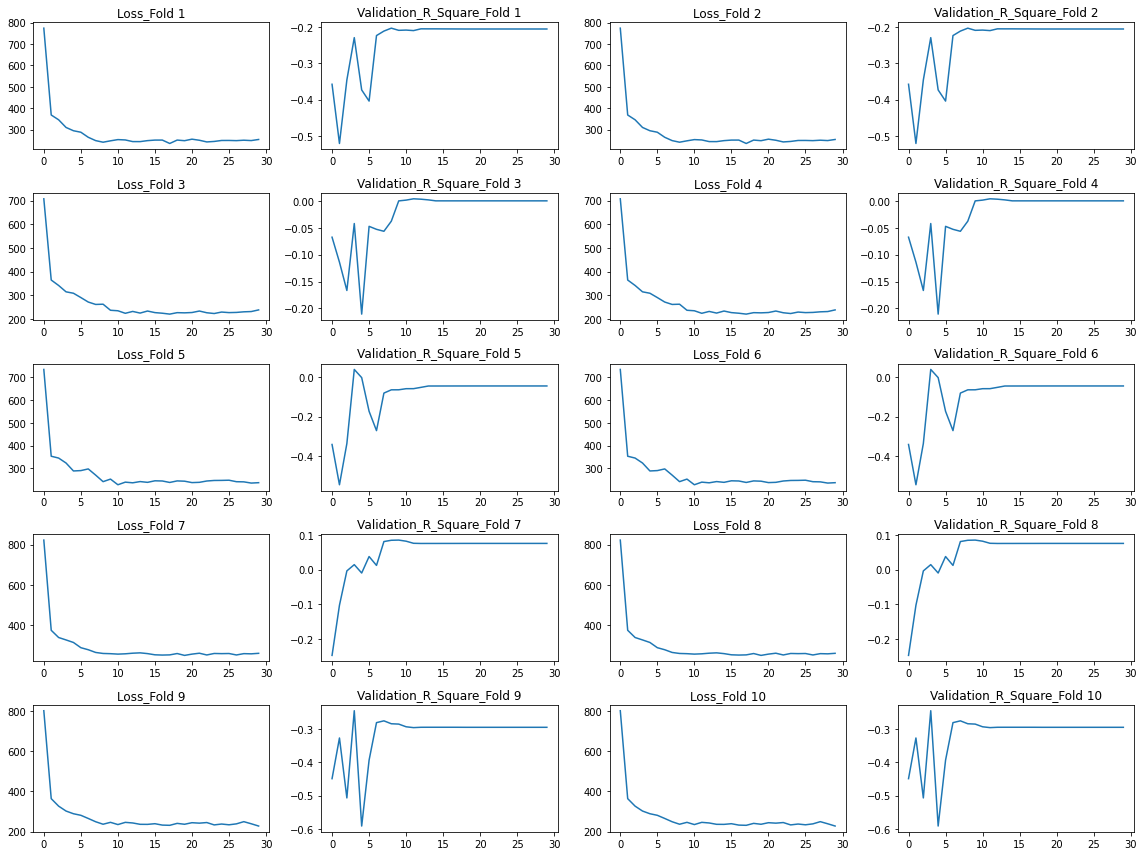

In [20]:
fig, axes = plt.subplots(nrows = 5, ncols = 4, figsize = (16, 12))
index = 0
evOd = 0
for i in range(5):
    for j in range(4):
        if evOd == 0:
            axes[i, j].plot(histories_Ch[i].history['loss'])
            axes[i, j].set_title(f'Loss_Fold {index + 1}')
            evOd = 1
        else:
            axes[i, j].plot(histories_Ch[i].history['val_RSquare'])
            axes[i, j].set_title(f'Validation_R_Square_Fold {index + 1}')
            evOd = 0
            index += 1
plt.tight_layout()
plt.show()

In [8]:
for i in range(1, 11):
    model_Am = tf.keras.models.load_model('10-Folds/10-Folds 1R,2F/stacked_model_Ammonia_' + str(i) + '.h5', custom_objects = {"RSquare": RSquare})
    model_Ch = tf.keras.models.load_model('10-Folds/10-Folds 1R,2F/stacked_model_Chlorophyll_' + str(i) + '.h5', custom_objects = {"RSquare": RSquare})
    out_Am = model_Am.predict(X_Train)
    out_Ch = model_Ch.predict(X_Train)
    R2_Am = r2_score(Y_Train_Am.reshape(2191, 1), out_Am)
    R2_Ch = r2_score(Y_Train_Ch.reshape(2191, 1), out_Ch)
    MSE_Am = mean_squared_error(Y_Train_Am.reshape(2191, 1), out_Am)
    MSE_Ch = mean_squared_error(Y_Train_Ch.reshape(2191, 1), out_Ch)
    print('MSE for Ammonia and Chlorophyll for', i, 'fold(s) is', MSE_Am, MSE_Ch)
    print('R2 Score for Ammonia and Chlorophyll for', i, 'fold(s) is', R2_Am, R2_Ch)

69/69 [==============================] - 12s 104ms/step
MSE for Ammonia and Chlorophyll for 1 fold(s) is 1230.4019868565954 89.74515614226307
R2 Score for Ammonia and Chlorophyll for 1 fold(s) is 0.45884992814482783 0.4701743321071449
69/69 [==============================] - 12s 104ms/step
MSE for Ammonia and Chlorophyll for 2 fold(s) is 1187.022991177654 84.41163436073371
R2 Score for Ammonia and Chlorophyll for 2 fold(s) is 0.4779286901099614 0.5016616776262768
69/69 [==============================] - 12s 103ms/step
MSE for Ammonia and Chlorophyll for 3 fold(s) is 1185.077570995309 87.37552390584607
R2 Score for Ammonia and Chlorophyll for 3 fold(s) is 0.478784316387154 0.48416385573480336
69/69 [==============================] - 12s 103ms/step
MSE for Ammonia and Chlorophyll for 4 fold(s) is 1201.045302589751 90.04227324677683
R2 Score for Ammonia and Chlorophyll for 4 fold(s) is 0.471761457848237 0.4684202511616301
69/69 [==============================] - 12s 103ms/step
MSE for Amm

In [9]:
for i in range(1, 11):
    model_Am = tf.keras.models.load_model('10-Folds/10-Folds Real/stacked_model_Ammonia_' + str(i) + '.h5', custom_objects = {"RSquare": RSquare})
    model_Ch = tf.keras.models.load_model('10-Folds/10-Folds Real/stacked_model_Chlorophyll_' + str(i) + '.h5', custom_objects = {"RSquare": RSquare})
    out_Am = model_Am.predict(X_Train)
    out_Ch = model_Ch.predict(X_Train)
    R2_Am = r2_score(Y_Train_Am.reshape(2191, 1), out_Am)
    R2_Ch = r2_score(Y_Train_Ch.reshape(2191, 1), out_Ch)
    MSE_Am = mean_squared_error(Y_Train_Am.reshape(2191, 1), out_Am)
    MSE_Ch = mean_squared_error(Y_Train_Ch.reshape(2191, 1), out_Ch)
    print('MSE for Ammonia and Chlorophyll for', i, 'fold(s) is', MSE_Am, MSE_Ch)
    print('R2 Score for Ammonia and Chlorophyll for', i, 'fold(s) is', R2_Am, R2_Ch)

69/69 [==============================] - 12s 102ms/step
MSE for Ammonia and Chlorophyll for 1 fold(s) is 1450.5204972528632 109.37943060410878
R2 Score for Ammonia and Chlorophyll for 1 fold(s) is 0.36203835843831955 0.35426008082600935
69/69 [==============================] - 12s 105ms/step
MSE for Ammonia and Chlorophyll for 2 fold(s) is 1460.406801223763 112.35926191810105
R2 Score for Ammonia and Chlorophyll for 2 fold(s) is 0.3576902070525252 0.3366681440128255
69/69 [==============================] - 12s 102ms/step
MSE for Ammonia and Chlorophyll for 3 fold(s) is 1470.4725735326979 124.52750887416738
R2 Score for Ammonia and Chlorophyll for 3 fold(s) is 0.35326312267973903 0.2648308455143612
69/69 [==============================] - 12s 104ms/step
MSE for Ammonia and Chlorophyll for 4 fold(s) is 1495.1533589322544 115.52196320831322
R2 Score for Ammonia and Chlorophyll for 4 fold(s) is 0.34240812656051645 0.3179966034477172
69/69 [==============================] - 12s 104ms/step
M